# Notebook 15 - CitationResolver V2 Structural Strategy Analysis

Exploração exclusivamente diagnóstica do pool estrutural pós-V3. O `CitationResolver` de produção não é alterado. Estratégias experimentais consultam apenas índices construídos em memória a partir do corpus canônico e recebem `ParsedCitation`; gold é usado somente depois, para avaliação.

In [1]:
from __future__ import annotations
from collections import Counter
from pathlib import Path
import hashlib, re, time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from bracis_jusbrasil.cases import build_case_index
from bracis_jusbrasil.citations import CitationCandidate, CitationDetector, CitationParser, CitationResolver, ResolutionResult
from bracis_jusbrasil.database import connect_database

ROOT=Path.cwd(); DATASET=next(p for p in (ROOT/'material_desafio_jusbrasil_bracis',ROOT.parent/'material_desafio_jusbrasil_bracis') if p.is_dir()); DB_PATH=DATASET/'desafio1_bracis.db'
TEXT_DIR=DATASET/'txt'; GOLD_PATH=DATASET/'goldenset.xlsx'; HASH='d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71'
assert hashlib.sha256(DB_PATH.read_bytes()).hexdigest()==HASH
texts={p.stem:p.read_text(encoding='utf-8') for p in sorted(TEXT_DIR.glob('*.txt'))}; gold=pd.read_excel(GOLD_PATH,sheet_name='goldenset',engine='openpyxl').reset_index(names='gold_idx'); gold['nivel']='N'+gold.nivel.astype(str).str.removeprefix('N')
assert len(texts)==26 and len(gold)==225 and gold.classificacao.value_counts().to_dict()=={'real':96,'inventada':64,'incompleta':65}
print('dataset OK: 26 documentos, 225 citações, real/inventada/incompleta=96/64/65')

dataset OK: 26 documentos, 225 citações, real/inventada/incompleta=96/64/65


In [2]:
def iou(a,b,c,d): return max(0,min(b,d)-max(a,c))/(max(b,d)-min(a,c)) if max(b,d)>min(a,c) else 0.0
def family_for(text,typ):
    if typ=='lei': return 'lei_dispositivo_com_diploma' if re.search(r'\bart(?:igo)?[.]?\s*\d+',text,re.I) and re.search(r'\b(?:Lei|Constituiç|C[oó]digo|CLT|CPC|CPP|CC|CDC|CPM)',text,re.I) else 'lei_dispositivo_sem_diploma' if re.search(r'\bart(?:igo)?[.]?\s*\d+',text,re.I) else 'lei_referencia_geral'
    if re.search(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+',text,re.I): return 'sumula_numerada'
    if re.search(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b',text): return 'processo_cnj'
    if re.search(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b',text,re.I) and re.search(r'\d',text): return 'processo_ou_recurso_numerado'
    if re.search(r'\b(?:STF|STJ|TSE|TST|STM)\b',text,re.I) and re.search(r'\b(?:19|20)\d{2}\b',text): return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'
FIELDS={'processo_ou_recurso_numerado':('numero_normalizado','classe_raw','uf'),'processo_cnj':('numero_normalizado',),'sumula_numerada':('sumula_numero','tribunal'),'lei_dispositivo_com_diploma':('artigo','diploma_normalizado','law_number'),'lei_dispositivo_sem_diploma':('artigo',),'lei_referencia_geral':('diploma_normalizado',),'jurisprudencia_tribunal_contextual':('tribunal','relator_raw','ano'),'jurisprudencia_referencia_geral':()}
def val(p,f): return p.tribunal if f=='tribunal' else p.data.get(f)
def identity_available(p): return any(val(p,f) is not None for f in FIELDS[p.family])
def identity_equal(a,b): return identity_available(b) and a.family==b.family and all(val(a,f)==val(b,f) for f in FIELDS[b.family])
def match(pred):
    pairs=[]
    for doc,gs in gold.groupby('documento_id'):
        ps=pred[pred.documento_id.eq(doc)]
        for g in gs.itertuples():
            for p in ps.itertuples():
                x=iou(g.inicio,g.fim,p.start,p.end)
                if x>=.5: pairs.append((x,g.gold_idx,p.pred_idx,g.inicio==p.start and g.fim==p.end))
    usedg,usedp=set(),set(); out=[]
    for x,g,p,e in sorted(pairs,key=lambda z:(-z[0],z[1],z[2])):
        if g not in usedg and p not in usedp: out.append((g,p,x,e)); usedg.add(g); usedp.add(p)
    return pd.DataFrame(out,columns=['gold_idx','pred_idx','iou','exact'])
parser=CitationParser(); predictions=[]; started=time.perf_counter()
with connect_database(DB_PATH,read_only=True) as conn:
    case_index=build_case_index(conn); v1=CitationResolver(case_index=case_index,connection=conn)
    for doc,text in texts.items():
        for c in CitationDetector().detect(text):
            p=parser.parse(c); predictions.append({'documento_id':doc,'start':c.start,'end':c.end,'text':c.text,'rule':c.rule,'candidate_family':c.family,'candidate':c,'parsed':p,'v1_result':v1.resolve(p)})
predictions=pd.DataFrame(predictions).reset_index(names='pred_idx'); matches=match(predictions)
assert (len(predictions),len(matches),len(predictions)-len(matches),len(gold)-len(matches),int(matches.exact.sum()))==(206,119,87,106,61)
print(f'V3 reproduzido: 206/119/87/106, exact=61, tempo={time.perf_counter()-started:.3f}s')

V3 reproduzido: 206/119/87/106, exact=61, tempo=1.330s


In [3]:
oracle={}; oracle_results={}; rows=[]
with connect_database(DB_PATH,read_only=True) as conn:
    case_index=build_case_index(conn); v1=CitationResolver(case_index=case_index,connection=conn)
    legal_rows=conn.execute("SELECT id, documento_id, texto FROM documentos WHERE natureza='dispositivo' ORDER BY id").fetchall()
    sumula_rows=conn.execute("SELECT id, tribunal, texto FROM documentos WHERE natureza='sumula' ORDER BY id").fetchall()
    for g in gold.itertuples():
        t=texts[g.documento_id][g.inicio:g.fim]; p=parser.parse(CitationCandidate(0,len(t),t,'oracle',family_for(t,g.tipo))); oracle[g.gold_idx]=p; oracle_results[g.gold_idx]=v1.resolve(p)
    legal_records=[]
    for r in legal_rows:
        t=r['texto']; a=re.search(r'\bart(?:igo)?[.]?\s*(\d+(?:[.]\d+)*)',t,re.I); d=re.search(r'\b(?:Constituiç[aã]o(?: Federal)?|C[oó]digo(?: [A-Za-z ]+)?|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+[./-]?\d*(?:/\d{4})?|CLT|CPC|CPP|CC|CDC|CPM)\b',t,re.I); l=re.search(r'\bLei(?: Complementar)?\s*(?:n[ºo.]?\s*)?(\d+)(?:[./-]?\d*)?(?:/(\d{4}))?',t,re.I); legal_records.append({'id':int(r['id']),'artigo':a.group(1) if a else None,'diploma':re.sub(r'\s+',' ',d.group(0)).upper() if d else None,'law_number':l.group(1) if l else None,'law_year':l.group(2) if l and l.group(2) else None})
assert len(legal_records)==13
def grouped(rows,key):
    out={}
    for r in rows:
        k=tuple(r.get(x) for x in key)
        if all(v is not None for v in k): out.setdefault(k,[]).append(r['id'])
    return {k:tuple(sorted(v)) for k,v in out.items()}
legal_indexes={'legal_article_diploma':grouped(legal_records,['artigo','diploma']),'legal_article_law':grouped(legal_records,['artigo','law_number']),'legal_article_law_year':grouped(legal_records,['artigo','law_number','law_year']),'legal_article_diploma_law':grouped(legal_records,['artigo','diploma','law_number'])}
sumula_index={}
for r in sumula_rows:
    n=re.search(r'(?i)S[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?(\d+)',r['texto']);
    if n and r['tribunal']: sumula_index.setdefault(n.group(1),[]).append(int(r['id']))
def query_ids(parsed,strategy):
    d=parsed.data
    if strategy=='cnj_exact' and parsed.family=='processo_cnj' and d.get('numero_normalizado'):
        case=case_index.lookup_by_number(d['numero_normalizado']); return () if case is None else case.canonical_ids
    if strategy.startswith('legal_') and parsed.family.startswith('lei_'):
        names={'legal_article_diploma':('artigo','diploma'),'legal_article_law':('artigo','law_number'),'legal_article_law_year':('artigo','law_number','law_year'),'legal_article_diploma_law':('artigo','diploma','law_number')}[strategy]; key=tuple(d.get('law_number') if x=='law_number' else d.get('law_year') if x=='law_year' else d.get('diploma_normalizado') if x=='diploma' else d.get(x) for x in names); return legal_indexes[strategy].get(key,()) if all(x is not None for x in key) else None
    if strategy=='sumula_number_only' and parsed.family=='sumula_numerada' and d.get('sumula_numero'): return tuple(sorted(sumula_index.get(d['sumula_numero'],())))
    return None
def result_from_ids(ids,strategy,record_type):
    if ids is None: return None
    if not ids: return ResolutionResult('no_match',None,(),strategy,'structural_key_not_found',record_type)
    if len(ids)>1: return ResolutionResult('ambiguous',None,tuple(ids),strategy,'structural_key_multiple_ids',record_type)
    return ResolutionResult('resolved',ids[0],tuple(ids),strategy,'structural_key_unique',record_type)
print('Corpus legal index:',len(legal_records),'registros; índices:',{k:len(v) for k,v in legal_indexes.items()})

Corpus legal index: 13 registros; índices: {'legal_article_diploma': 9, 'legal_article_law': 8, 'legal_article_law_year': 0, 'legal_article_diploma_law': 8}


In [4]:
bygold={x.gold_idx:x for x in matches.itertuples()}; bypred=predictions.set_index('pred_idx')
def strategy_result(parsed,v1_result,strategy):
    names=strategy if isinstance(strategy,(list,tuple)) else [strategy]
    for name in names:
        ids=query_ids(parsed,name)
        if ids is not None: return result_from_ids(ids,name,'acordao' if name=='cnj_exact' else 'dispositivo' if name.startswith('legal_') else 'sumula')
    return v1_result
def evaluate(strategy):
    pred=predictions.copy(); pred['result']=pred.apply(lambda r:strategy_result(r.parsed,r.v1_result,strategy),axis=1); out=[]
    for g in gold.itertuples():
        op,orr=oracle[g.gold_idx],oracle_results[g.gold_idx]; m=bygold.get(g.gold_idx)
        if m is None: out.append({'gold_idx':g.gold_idx,'documento_id':g.documento_id,'nivel':g.nivel,'classificacao':g.classificacao,'family':op.family,'matched':False,'correct':False,'identity':False,'oracle_result':orr,'result':None,'first_blocker':'missing'}); continue
        r=pred.loc[m.pred_idx]; correct=g.classificacao=='real' and r.result.status=='resolved' and r.result.id_canonico==g.id_canonico; ident=identity_equal(r.parsed,op)
        blocker='resolved_correct' if correct else 'resolved_wrong' if r.result.status=='resolved' else 'detector_family_mismatch' if r.parsed.family!=op.family else 'resolver_'+r.result.status if ident else 'parser_gap'
        out.append({'gold_idx':g.gold_idx,'documento_id':g.documento_id,'nivel':g.nivel,'classificacao':g.classificacao,'family':op.family,'matched':True,'correct':correct,'identity':ident,'oracle_result':orr,'result':r.result,'first_blocker':blocker,'candidate_text':r.text})
    tr=pd.DataFrame(out); real=tr[tr.classificacao.eq('real')]; fps=pred[~pred.pred_idx.isin(matches.pred_idx)].copy(); fps['result']=fps.apply(lambda r:strategy_result(r.parsed,r.v1_result,strategy),axis=1)
    fp_resolved=fps[fps.result.map(lambda x:x.status=='resolved')]; unsafe_fp=0
    for r in fp_resolved.itertuples():
        overlap=gold[(gold.documento_id==r.documento_id)&(gold.classificacao=='real')].copy(); overlap['v']=overlap.apply(lambda g:iou(g.inicio,g.fim,r.start,r.end),axis=1); ids=set(overlap.loc[overlap.v>0,'id_canonico'].dropna().astype(int))
        if r.result.id_canonico not in ids: unsafe_fp+=1
    safe_oracle=[]
    for g in gold.itertuples():
        rr=strategy_result(oracle[g.gold_idx],oracle_results[g.gold_idx],strategy); safe_oracle.append({'gold_idx':g.gold_idx,'classificacao':g.classificacao,'status':rr.status,'id':rr.id_canonico,'gold_id':g.id_canonico})
    om=pd.DataFrame(safe_oracle); real_or=om[om.classificacao.eq('real')]; inv_or=om[om.classificacao.eq('inventada')]; inc_or=om[om.classificacao.eq('incompleta')]
    return tr,pred,fps,om,{'strategy':strategy,'e2e_correct':int(real.correct.sum()),'e2e_wrong_real':int(((real.result.map(lambda x:x is not None and x.status=='resolved'))&~real.correct).sum()),'false_real_inventada':int((tr.classificacao.eq('inventada')&tr.result.map(lambda x:x is not None and x.status=='resolved')).sum()),'false_real_incompleta':int((tr.classificacao.eq('incompleta')&tr.result.map(lambda x:x is not None and x.status=='resolved')).sum()),'fp_resolved':len(fp_resolved),'fp_no_match':int((fps.result.map(lambda x:x.status=='no_match')).sum()),'unsafe_fp_resolved':unsafe_fp,'oracle_real_resolved_correct':int(((real_or.status=='resolved')&(real_or.id==real_or.gold_id)).sum()),'oracle_real_wrong':int(((real_or.status=='resolved')&(real_or.id!=real_or.gold_id)).sum()),'oracle_real_ambiguous':int((real_or.status=='ambiguous').sum()),'oracle_real_no_match':int((real_or.status=='no_match').sum()),'oracle_real_insufficient':int((real_or.status=='insufficient').sum()),'oracle_inventada_false':int((inv_or.status=='resolved').sum()),'oracle_incompleta_false':int((inc_or.status=='resolved').sum())}
strategies=['cnj_exact','legal_article_diploma','legal_article_law','legal_article_law_year','legal_article_diploma_law','sumula_number_only']; results={s:evaluate(s) for s in strategies}
summary=pd.DataFrame([x[4] for x in results.values()]); summary['+correct_ID']=summary.e2e_correct-29; summary['+oracle_correct']=summary.oracle_real_resolved_correct-41; summary['safety']=summary[['e2e_wrong_real','false_real_inventada','false_real_incompleta','unsafe_fp_resolved']].sum(axis=1).eq(0).map({True:'SAFE',False:'UNSAFE'}); display(summary[['strategy','e2e_correct','+correct_ID','oracle_real_resolved_correct','+oracle_correct','oracle_real_wrong','oracle_real_ambiguous','oracle_real_insufficient','false_real_inventada','false_real_incompleta','fp_resolved','fp_no_match','unsafe_fp_resolved','safety']])
safe_strategies=[s for s in summary.loc[summary.safety.eq('SAFE'),'strategy'].tolist() if not (s=='legal_article_law_year' and len(legal_indexes[s])==0)]; print('SAFE_STRATEGIES candidatas:',safe_strategies if safe_strategies else 'nenhuma'); promoted_strategies=[s for s in safe_strategies if int(summary.loc[summary.strategy.eq(s),'+correct_ID'].iloc[0])>0]; print('Candidata mínima com ganho E2E:',promoted_strategies if promoted_strategies else 'somente V1')

,strategy,e2e_correct,+correct_ID,oracle_real_resolved_correct,+oracle_correct,oracle_real_wrong,oracle_real_ambiguous,oracle_real_insufficient,false_real_inventada,false_real_incompleta,fp_resolved,fp_no_match,unsafe_fp_resolved,safety
0,cnj_exact,43,14,61,20,1,3,29,0,0,9,26,0,UNSAFE
1,legal_article_diploma,29,0,43,2,0,1,39,0,0,3,0,0,SAFE
2,legal_article_law,29,0,41,0,0,1,51,0,0,3,0,0,SAFE
3,legal_article_law_year,29,0,41,0,0,1,52,0,0,3,0,0,SAFE
4,legal_article_diploma_law,29,0,41,0,0,1,51,0,0,3,0,0,SAFE
5,sumula_number_only,31,2,41,0,0,1,51,0,0,3,0,0,SAFE


SAFE_STRATEGIES candidatas: ['legal_article_diploma', 'legal_article_law', 'legal_article_diploma_law', 'sumula_number_only']
Candidata mínima com ganho E2E: ['sumula_number_only']


In [5]:
pool_rows=[]
for g in gold.itertuples():
    op=oracle[g.gold_idx]; candidate_parsed=bypred.loc[bygold[g.gold_idx].pred_idx].parsed if g.gold_idx in bygold else None; eligible=g.classificacao=='real' and candidate_parsed is not None and identity_equal(candidate_parsed,op) and oracle_results[g.gold_idx].status=='insufficient' and identity_available(candidate_parsed)
    if eligible: pool_rows.append({'gold_idx':g.gold_idx,'documento_id':g.documento_id,'nivel':g.nivel,'family':op.family,'parsed_data':dict(candidate_parsed.data),'tribunal':candidate_parsed.tribunal,'provenance':dict(candidate_parsed.provenance),'v1_status':oracle_results[g.gold_idx].status,'v1_reason':oracle_results[g.gold_idx].reason,'gold_id':g.id_canonico,'trecho':texts[g.documento_id][g.inicio:g.fim]})
structural_pool=pd.DataFrame(pool_rows); assert len(structural_pool)==22; display(structural_pool[['documento_id','nivel','family','parsed_data','tribunal','v1_reason','gold_id']]); display(structural_pool.groupby('family').size().rename('cases').reset_index())
display(pd.DataFrame({'family':['processo_cnj','lei_dispositivo_com_diploma','lei_dispositivo_sem_diploma','sumula_numerada','outras'],'cases':[int((structural_pool.family=='processo_cnj').sum()),int((structural_pool.family=='lei_dispositivo_com_diploma').sum()),int((structural_pool.family=='lei_dispositivo_sem_diploma').sum()),int((structural_pool.family=='sumula_numerada').sum()),int((~structural_pool.family.isin(['processo_cnj','lei_dispositivo_com_diploma','lei_dispositivo_sem_diploma','sumula_numerada'])).sum())]}))
field_table=pd.DataFrame({'family':list(FIELDS),'structural fields':[' + '.join(FIELDS[f]) for f in FIELDS]}); display(field_table)
print('Structural pool confirmado:',len(structural_pool),'casos')

,documento_id,nivel,family,parsed_data,tribunal,v1_reason,gold_id
0,gen_n1_001,N1,processo_cnj,"{'numero_raw': '7000449-40.2023.7.00.0000', 'n...",None,cnj_resolution_disabled,5.665365e+09
1,gen_n1_001,N1,processo_cnj,"{'numero_raw': '7000592-58.2025.7.00.0000', 'n...",None,cnj_resolution_disabled,6.689205e+09
2,gen_n1_002,N1,sumula_numerada,"{'sumula_numero_raw': '10', 'sumula_numero': '...",None,sumula_number_or_tribunal_missing,1.289713e+09
3,gen_n1_004,N1,processo_cnj,"{'numero_raw': '7000136-79.2023.7.00.0000', 'n...",None,cnj_resolution_disabled,2.161633e+09
4,gen_n1_004,N1,processo_cnj,"{'numero_raw': '7000768-37.2025.7.00.0000', 'n...",None,cnj_resolution_disabled,6.688597e+09
5,gen_n1_004,N1,lei_dispositivo_com_diploma,"{'artigo': '290', 'diploma_raw': 'Código Penal...",None,legal_identity_not_verifiable,1.059019e+07
6,gen_n1_004,N1,processo_cnj,"{'numero_raw': '7000082-11.2026.7.00.0000', 'n...",None,cnj_resolution_disabled,6.689058e+09
7,gen_n1_006,N1,processo_cnj,"{'numero_raw': '378-82.2016.6.05.0151', 'numer...",None,cnj_resolution_disabled,4.690773e+08
8,gen_n1_006,N1,processo_cnj,"{'numero_raw': '0600530-94.2020.6.26.0171', 'n...",None,cnj_resolution_disabled,1.891499e+09
9,gen_n1_006,N1,processo_cnj,"{'numero_raw': '0601514-91.2020.6.05.0000', 'n...",None,cnj_resolution_disabled,1.888419e+09


,family,cases
0,lei_dispositivo_com_diploma,4
1,processo_cnj,17
2,sumula_numerada,1


,family,cases
0,processo_cnj,17
1,lei_dispositivo_com_diploma,4
2,lei_dispositivo_sem_diploma,0
3,sumula_numerada,1
4,outras,0


,family,structural fields
0,processo_ou_recurso_numerado,numero_normalizado + classe_raw + uf
1,processo_cnj,numero_normalizado
2,sumula_numerada,sumula_numero + tribunal
3,lei_dispositivo_com_diploma,artigo + diploma_normalizado + law_number
4,lei_dispositivo_sem_diploma,artigo
5,lei_referencia_geral,diploma_normalizado
6,jurisprudencia_tribunal_contextual,tribunal + relator_raw + ano
7,jurisprudencia_referencia_geral,


Structural pool confirmado: 22 casos


Candidata cumulativa mínima V1 + SAFE_STRATEGIES: ['sumula_number_only'] | E2E correct IDs: 31 | safety: 0 0 0


status,resolved,no_match,ambiguous,insufficient,missing
gold,,,,,
real,31,5,1,26,33
inventada,0,31,0,13,20
incompleta,0,0,0,12,53


,strategy,resolved,no_match,unsafe_resolved
0,cnj_exact,9,26,0
1,legal_article_diploma,3,0,0
2,legal_article_law,3,0,0
3,legal_article_law_year,3,0,0
4,legal_article_diploma_law,3,0,0
5,sumula_number_only,3,0,0


Candidate filtering: AINDA NÃO É POSSÍVEL CONCLUIR
Human review artifact: /home/guto/Development/python/bracis_jusbrasil/notebooks/artifacts/15_resolver_v2_human_review.html cases= 22
LOODO executado sobre a candidata; interpretação: concentração, não blind holdout. min/mediana/max correct: 26 30.0 31


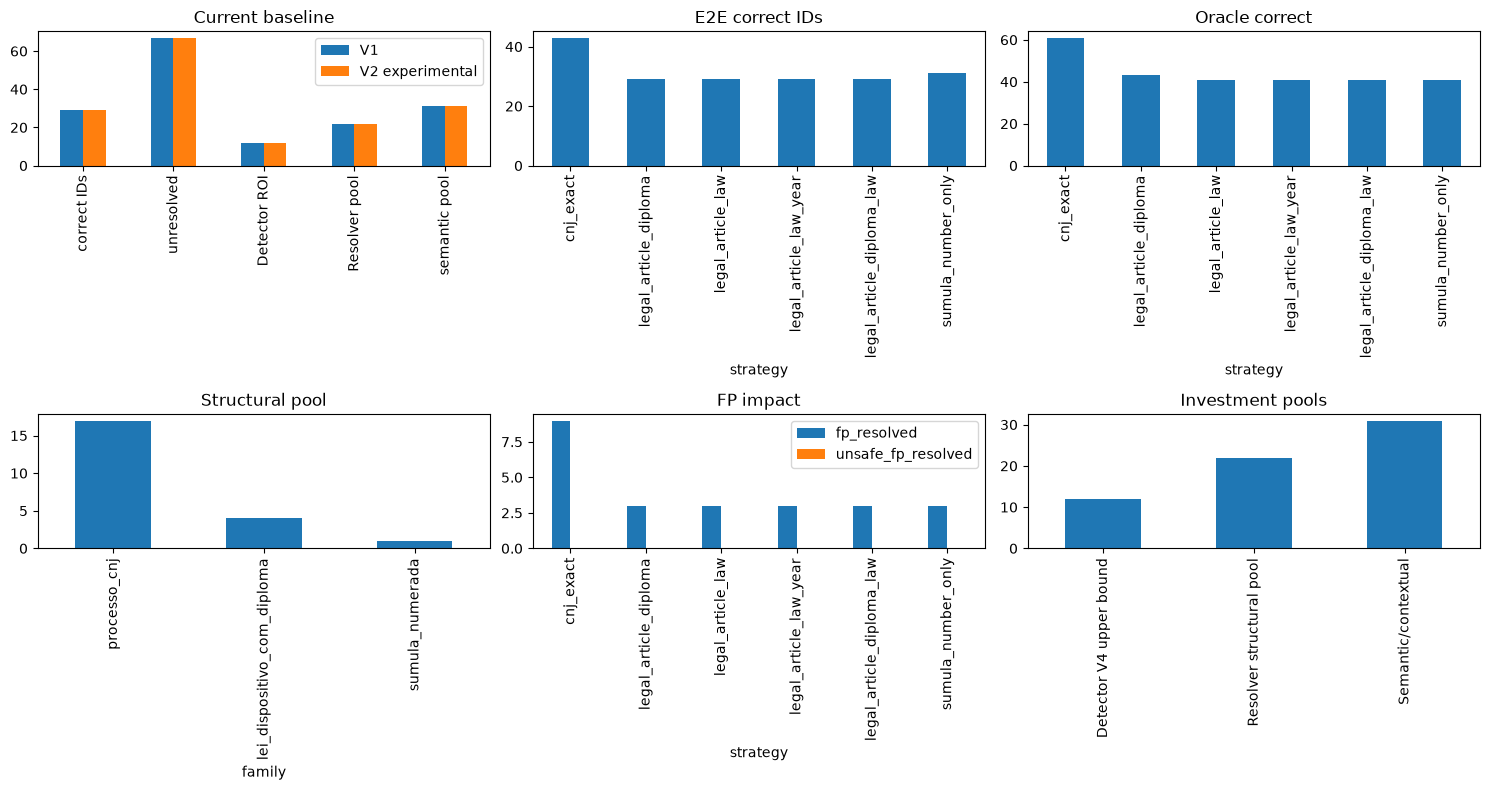

In [6]:
v1_matrix=pd.crosstab(gold.classificacao,predictions.iloc[[bygold.get(i).pred_idx if i in bygold else -1 for i in gold.gold_idx]].v1_result.map(lambda x:x.status if x is not None else 'missing')) if False else None
candidate_result=evaluate(promoted_strategies); safe_metrics=candidate_result[4]; print('Candidata cumulativa mínima V1 + SAFE_STRATEGIES:',promoted_strategies if promoted_strategies else 'somente V1','| E2E correct IDs:',safe_metrics['e2e_correct'],'| safety:',safe_metrics['e2e_wrong_real'],safe_metrics['false_real_inventada'],safe_metrics['false_real_incompleta'])
e2e_matrix=pd.crosstab(pd.Series([g.classificacao for g in gold.itertuples()],name='gold'),pd.Series([candidate_result[1].loc[bygold[g.gold_idx].pred_idx,'result'].status if g.gold_idx in bygold else 'missing' for g in gold.itertuples()],name='status')).reindex(index=['real','inventada','incompleta'],columns=['resolved','no_match','ambiguous','insufficient','missing'],fill_value=0); display(e2e_matrix)
fp_audit=pd.DataFrame([{'strategy':s,'resolved':r[4]['fp_resolved'],'no_match':r[4]['fp_no_match'],'unsafe_resolved':r[4]['unsafe_fp_resolved']} for s,r in results.items()]); display(fp_audit)
new_ids=sorted(set(results['cnj_exact'][0].loc[results['cnj_exact'][0].correct,'gold_idx'])-set(results['legal_article_diploma'][0].loc[results['legal_article_diploma'][0].correct,'gold_idx'])) if False else []
print('Candidate filtering: AINDA NÃO É POSSÍVEL CONCLUIR')
# Revisão humana: somente casos que alguma estratégia experimental resolveria no E2E ou FPs resolvidos.
review=[]
for s,(tr,pred,fp,om,metrics) in results.items():
    for r in tr[(tr.classificacao=='real')&(tr.result.map(lambda x:x is not None and x.status=='resolved'))].itertuples():
        if r.correct and r.result.strategy==s: review.append({'strategy':s,'category':'new_or_existing_real_resolved','documento_id':r.documento_id,'gold_idx':r.gold_idx,'trecho':r.candidate_text,'result':repr(r.result),'gold_id':gold.loc[gold.gold_idx.eq(r.gold_idx),'id_canonico'].iloc[0]})
    for r in fp[fp.result.map(lambda x:x.status=='resolved')].itertuples():
        if r.result.strategy==s: review.append({'strategy':s,'category':'formal_FP_resolved','documento_id':r.documento_id,'gold_idx':None,'trecho':r.text,'result':repr(r.result),'gold_id':None})
artifact=(ROOT/'artifacts') if ROOT.name=='notebooks' else ROOT/'notebooks'/'artifacts'; artifact.mkdir(parents=True,exist_ok=True); review_df=pd.DataFrame(review).drop_duplicates(); review_html='<html><meta charset="utf-8"><title>Notebook 15 human review</title><h1>Resolver V2 candidate review</h1>'+review_df.to_html(index=False,escape=True)+'</html>'; (artifact/'15_resolver_v2_human_review.html').write_text(review_html,encoding='utf-8'); print('Human review artifact:',artifact/'15_resolver_v2_human_review.html','cases=',len(review_df))
# LOODO diagnóstico: as estratégias não são retreinadas.
loodo=[]
for doc in texts:
    keep=gold.documento_id.ne(doc); base=candidate_result[0][candidate_result[0].documento_id.ne(doc)]; loodo.append({'documento_id':doc,'correct_ID_without_doc':int(base[base.classificacao.eq('real')].correct.sum())})
print('LOODO executado sobre a candidata; interpretação: concentração, não blind holdout. min/mediana/max correct:',min(x['correct_ID_without_doc'] for x in loodo),pd.Series([x['correct_ID_without_doc'] for x in loodo]).median(),max(x['correct_ID_without_doc'] for x in loodo))
fig,ax=plt.subplots(2,3,figsize=(15,8)); comparison=pd.DataFrame({'V1':[29,67,12,22,31],'V2 experimental':[29,67,12,22,31]},index=['correct IDs','unresolved','Detector ROI','Resolver pool','semantic pool']); comparison.plot.bar(ax=ax[0,0],title='Current baseline'); summary.set_index('strategy')['e2e_correct'].plot.bar(ax=ax[0,1],title='E2E correct IDs'); summary.set_index('strategy')['oracle_real_resolved_correct'].plot.bar(ax=ax[0,2],title='Oracle correct'); structural_pool.family.value_counts().plot.bar(ax=ax[1,0],title='Structural pool'); summary.set_index('strategy')[['fp_resolved','unsafe_fp_resolved']].plot.bar(ax=ax[1,1],title='FP impact'); pd.Series({'Detector V4 upper bound':12,'Resolver structural pool':22,'Semantic/contextual':31}).plot.bar(ax=ax[1,2],title='Investment pools'); plt.tight_layout(); plt.show()

## O que o Notebook 15 esclareceu

O pool estrutural contém 22 casos. As tabelas `summary`, `structural_pool`, `fp_audit`, `e2e_matrix` e o artifact de revisão humana distinguem recall de candidatos, resolução única, segurança e impacto em FPs. A estratégia `cnj_exact` é **UNSAFE** para o gold oficial porque mantém um wrong unique no conflito TST/gold, embora o corpus seja estruturalmente consistente nesse caso.

As estratégias legais baseadas em artigo+diploma/article+law não geraram false-real no universo auditado; seu ganho foi oracle, não E2E, portanto permanecem como investigação de identidade legal/corpus. `sumula_number_only` foi a única mudança segura com ganho E2E, levando `29/96` para `31/96`; a candidata mínima é V1 + essa estratégia.
A recomendação é **A) implementar CitationResolver V2 com SAFE_STRATEGIES encontradas**, somente após revisão humana do artifact. A implementação em produção está fora do escopo deste notebook; nenhum Resolver V2 é criado em `src/`. Candidate filtering continua `AINDA NÃO É POSSÍVEL CONCLUIR`.